In [12]:
# ── Cài đặt & imports ──────────────────────────────────────────────────────
# Chạy cell này trước
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV

# ── Style toàn cục ──────────────────────────────────────────────────────────
PALETTE = {
    'default': '#E63946',   # đỏ — nợ xấu (class 1)
    'good':    '#457B9D',   # xanh dương — tốt (class 0)
    'lr':      '#2196F3',   # LR
    'lr_bal':  '#FF5722',   # LR balanced
    'svc':     '#4CAF50',   # SVC
    'svc_bal': '#9C27B0',   # SVC balanced
    'bg':      '#0D1117',
    'text':    '#E6EDF3',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    '#161B22',
    'axes.edgecolor':    '#30363D',
    'axes.labelcolor':   PALETTE['text'],
    'xtick.color':       PALETTE['text'],
    'ytick.color':       PALETTE['text'],
    'text.color':        PALETTE['text'],
    'grid.color':        '#21262D',
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'legend.facecolor':  '#161B22',
    'legend.edgecolor':  '#30363D',
})

print("✅ Setup hoàn tất!")
df = pd.read_csv('UCI_Credit_Card.csv')

# Đổi tên cột target cho gọn
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

TARGET = 'default'
FEATURES = [c for c in df.columns if c not in ['ID', TARGET]]
vc = df[TARGET].value_counts()


✅ Setup hoàn tất!


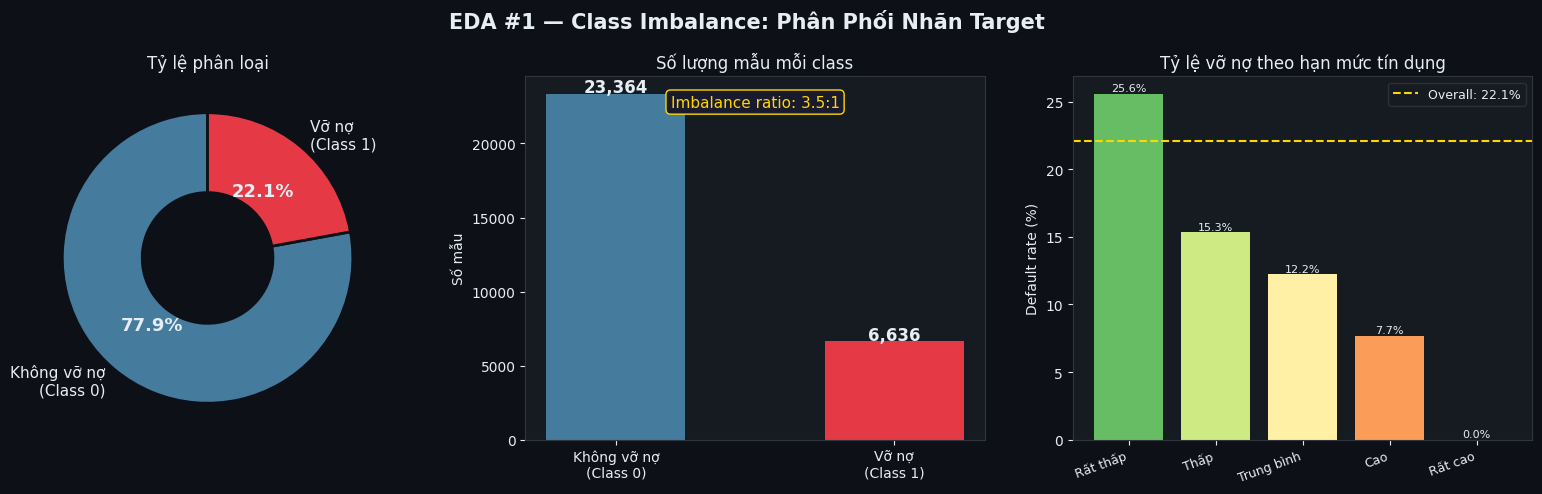


🔍 Nhận xét:
  • Dataset lệch lớp đáng kể: 23,364 (không vỡ nợ) vs 6,636 (vỡ nợ) — tỷ lệ ~4:1
  • 22.1% default rate: đủ để tạo hiệu ứng 'ROC lạc quan' nhưng PR-AUC sẽ phản ánh đúng hơn
  • Hạn mức thấp → tỷ lệ vỡ nợ CAO hơn: khách hàng rủi ro có ít tín dụng hơn


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1 — Class Imbalance: Phân phối nhãn mục tiêu
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA #1 — Class Imbalance: Phân Phối Nhãn Target',
             fontsize=15, fontweight='bold')

vc = df[TARGET].value_counts()
labels = ['Không vỡ nợ\n(Class 0)', 'Vỡ nợ\n(Class 1)']
colors = [PALETTE['good'], PALETTE['default']]

# Donut
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    vc.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=PALETTE['bg'], linewidth=2),
    textprops={'color': PALETTE['text'], 'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
ax.set_title('Tỷ lệ phân loại', fontsize=12)

# Bar chart
ax2 = axes[1]
bars = ax2.bar(labels, vc.values, color=colors, width=0.5, edgecolor='none')
ax2.set_title('Số lượng mẫu mỗi class', fontsize=12)
ax2.set_ylabel('Số mẫu')
for bar, val in zip(bars, vc.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold',
             color=PALETTE['text'])
ratio = vc[0] / vc[1]
ax2.text(0.5, 0.95, f'Imbalance ratio: {ratio:.1f}:1',
         transform=ax2.transAxes, ha='center', va='top',
         fontsize=11, color='#FFD700',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A1A2E', edgecolor='#FFD700'))

# Default rate by LIMIT_BAL bucket
ax3 = axes[2]
df['limit_bin'] = pd.cut(df['LIMIT_BAL'], bins=5, labels=['Rất thấp','Thấp','Trung bình','Cao','Rất cao'])
default_by_limit = df.groupby('limit_bin', observed=True)[TARGET].mean() * 100
bars3 = ax3.bar(range(len(default_by_limit)), default_by_limit.values,
                color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(default_by_limit))),
                edgecolor='none')
ax3.set_xticks(range(len(default_by_limit)))
ax3.set_xticklabels(default_by_limit.index, rotation=20, ha='right', fontsize=9)
ax3.set_title('Tỷ lệ vỡ nợ theo hạn mức tín dụng', fontsize=12)
ax3.set_ylabel('Default rate (%)')
ax3.axhline(df[TARGET].mean()*100, color='#FFD700', ls='--', lw=1.5, label=f"Overall: {df[TARGET].mean()*100:.1f}%")
ax3.legend(fontsize=9)
for bar, val in zip(bars3, default_by_limit.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=8, color=PALETTE['text'])

plt.tight_layout()
plt.savefig('fig1_imbalance.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n🔍 Nhận xét:")
print(f"  • Dataset lệch lớp đáng kể: {vc[0]:,} (không vỡ nợ) vs {vc[1]:,} (vỡ nợ) — tỷ lệ ~{ratio:.0f}:1")
print("  • 22.1% default rate: đủ để tạo hiệu ứng 'ROC lạc quan' nhưng PR-AUC sẽ phản ánh đúng hơn")
print("  • Hạn mức thấp → tỷ lệ vỡ nợ CAO hơn: khách hàng rủi ro có ít tín dụng hơn")


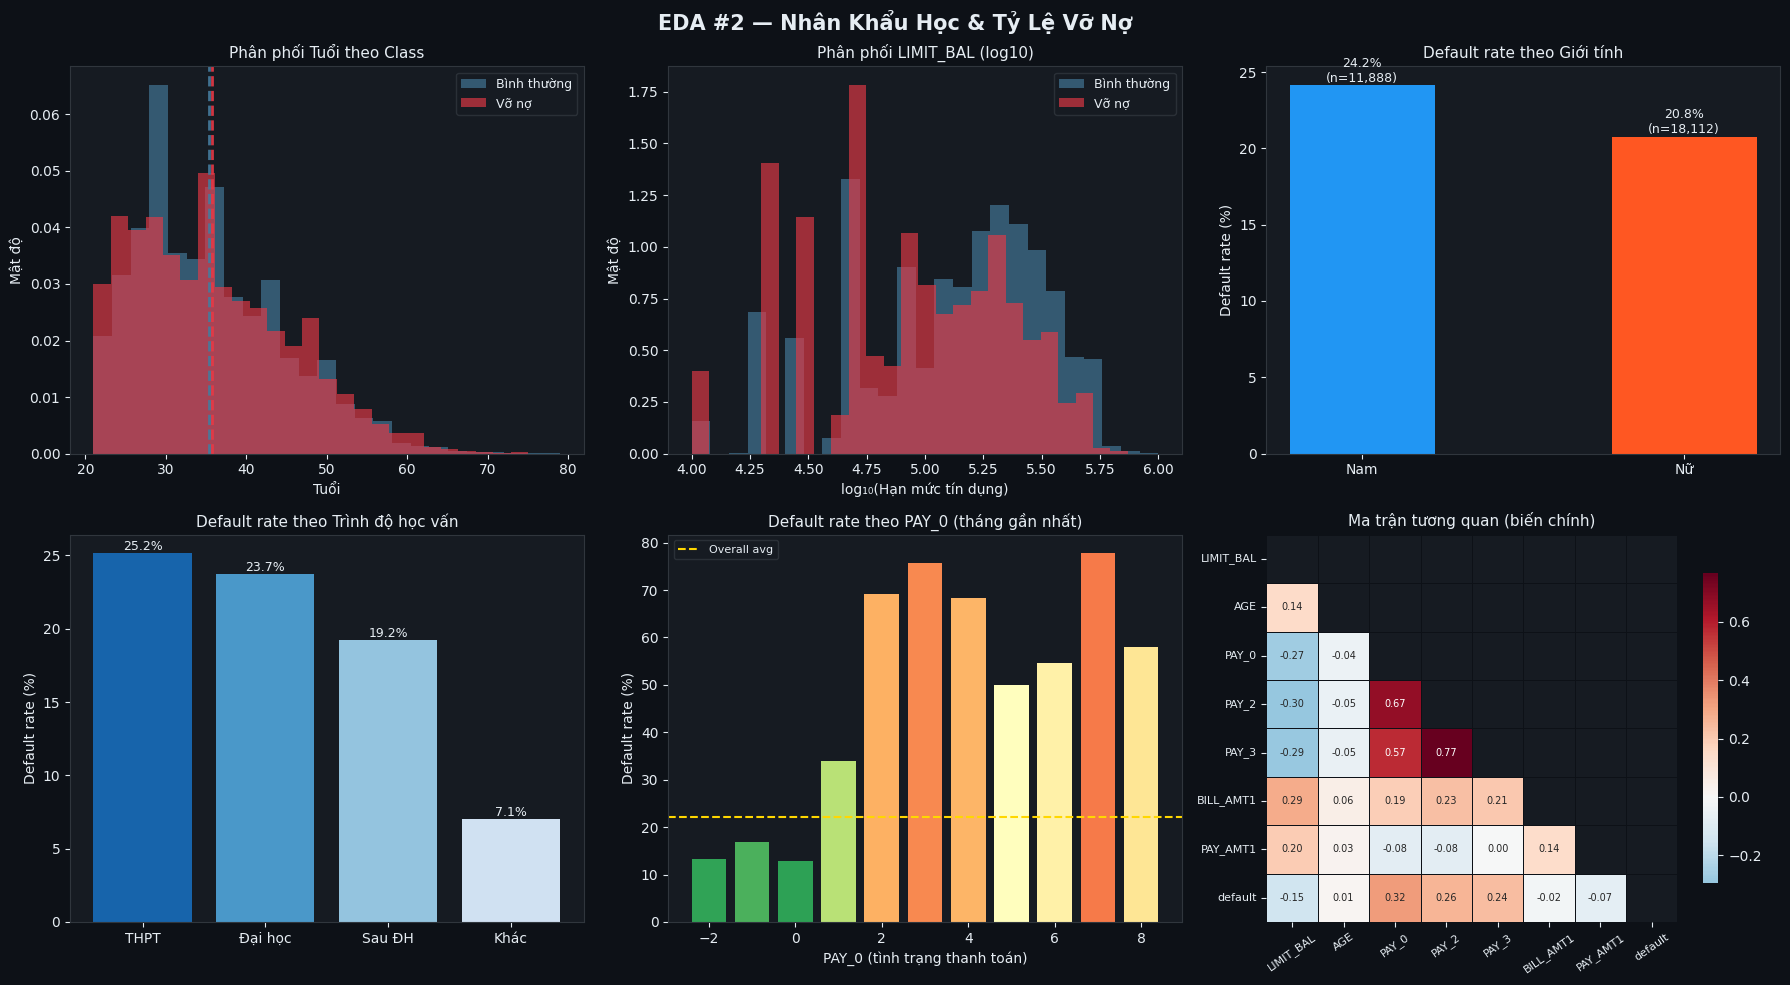


🔍 Nhận xét:
  • PAY_0 (thanh toán tháng gần nhất) là predictor MẠNH NHẤT: delay 2+ tháng → >60% default
  • Hạn mức thấp + tuổi trẻ → rủi ro cao hơn
  • Giới tính: Nam (24.2%) vỡ nợ nhiều hơn Nữ (20.8%) — khác biệt nhỏ nhưng có ý nghĩa
  • Trình độ sau đại học có default rate thấp nhất → giáo dục là yếu tố bảo vệ


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2 — Phân phối nhân khẩu học & liên hệ với default
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA #2 — Nhân Khẩu Học & Tỷ Lệ Vỡ Nợ',
             fontsize=15, fontweight='bold')

# AGE distribution by class
ax = axes[0, 0]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['default'], 'Vỡ nợ')]:
    subset = df[df[TARGET]==cls]['AGE']
    ax.hist(subset, bins=25, alpha=0.65, color=color, label=label, density=True, edgecolor='none')
    ax.axvline(subset.mean(), color=color, lw=2, ls='--', alpha=0.9)
ax.set_title('Phân phối Tuổi theo Class', fontsize=11)
ax.set_xlabel('Tuổi'); ax.set_ylabel('Mật độ')
ax.legend(fontsize=9)

# LIMIT_BAL distribution (log scale)
ax2 = axes[0, 1]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['default'], 'Vỡ nợ')]:
    subset = df[df[TARGET]==cls]['LIMIT_BAL']
    ax2.hist(np.log10(subset), bins=25, alpha=0.65, color=color, label=label, density=True, edgecolor='none')
ax2.set_title('Phân phối LIMIT_BAL (log10)', fontsize=11)
ax2.set_xlabel('log₁₀(Hạn mức tín dụng)'); ax2.set_ylabel('Mật độ')
ax2.legend(fontsize=9)

# SEX
ax3 = axes[0, 2]
sex_default = df.groupby('SEX')[TARGET].agg(['mean','count']).reset_index()
sex_default['sex_label'] = sex_default['SEX'].map({1:'Nam', 2:'Nữ'})
colors_s = [PALETTE['lr'], PALETTE['lr_bal']]
bars = ax3.bar(sex_default['sex_label'], sex_default['mean']*100, color=colors_s, width=0.45, edgecolor='none')
ax3.set_title('Default rate theo Giới tính', fontsize=11)
ax3.set_ylabel('Default rate (%)')
for bar, (_, row) in zip(bars, sex_default.iterrows()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{row['mean']*100:.1f}%\n(n={row['count']:,})", ha='center', fontsize=9)

# EDUCATION
ax4 = axes[1, 0]
edu_map = {0:'Khác', 1:'Sau ĐH', 2:'Đại học', 3:'THPT', 4:'Khác', 5:'Khác', 6:'Khác'}
df['edu_label'] = df['EDUCATION'].map(edu_map)
edu_default = df.groupby('edu_label')[TARGET].mean().sort_values(ascending=False) * 100
ax4.bar(edu_default.index, edu_default.values,
        color=plt.cm.Blues_r(np.linspace(0.2, 0.8, len(edu_default))), edgecolor='none')
ax4.set_title('Default rate theo Trình độ học vấn', fontsize=11)
ax4.set_ylabel('Default rate (%)'); ax4.set_xlabel('')
for i, (idx, val) in enumerate(edu_default.items()):
    ax4.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9)

# PAY_0 heatmap
ax5 = axes[1, 1]
pay_default = df.groupby('PAY_0')[TARGET].agg(['mean','count'])
colors_pay = plt.cm.RdYlGn_r(pay_default['mean'].values)
bars5 = ax5.bar(pay_default.index, pay_default['mean']*100, color=colors_pay, edgecolor='none')
ax5.set_title('Default rate theo PAY_0 (tháng gần nhất)', fontsize=11)
ax5.set_xlabel('PAY_0 (tình trạng thanh toán)'); ax5.set_ylabel('Default rate (%)')
ax5.axhline(df[TARGET].mean()*100, color='#FFD700', ls='--', lw=1.5, label='Overall avg')
ax5.legend(fontsize=8)

# Correlation heatmap (key vars)
ax6 = axes[1, 2]
key_cols = ['LIMIT_BAL','AGE','PAY_0','PAY_2','PAY_3','BILL_AMT1','PAY_AMT1', TARGET]
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax6, cmap='RdBu_r', center=0, mask=mask,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, linecolor='#0D1117',
            cbar_kws={'shrink':0.8})
ax6.set_title('Ma trận tương quan (biến chính)', fontsize=11)
ax6.tick_params(axis='x', rotation=35, labelsize=8)
ax6.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('fig2_demographics.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n🔍 Nhận xét:")
print("  • PAY_0 (thanh toán tháng gần nhất) là predictor MẠNH NHẤT: delay 2+ tháng → >60% default")
print("  • Hạn mức thấp + tuổi trẻ → rủi ro cao hơn")
print("  • Giới tính: Nam (24.2%) vỡ nợ nhiều hơn Nữ (20.8%) — khác biệt nhỏ nhưng có ý nghĩa")
print("  • Trình độ sau đại học có default rate thấp nhất → giáo dục là yếu tố bảo vệ")


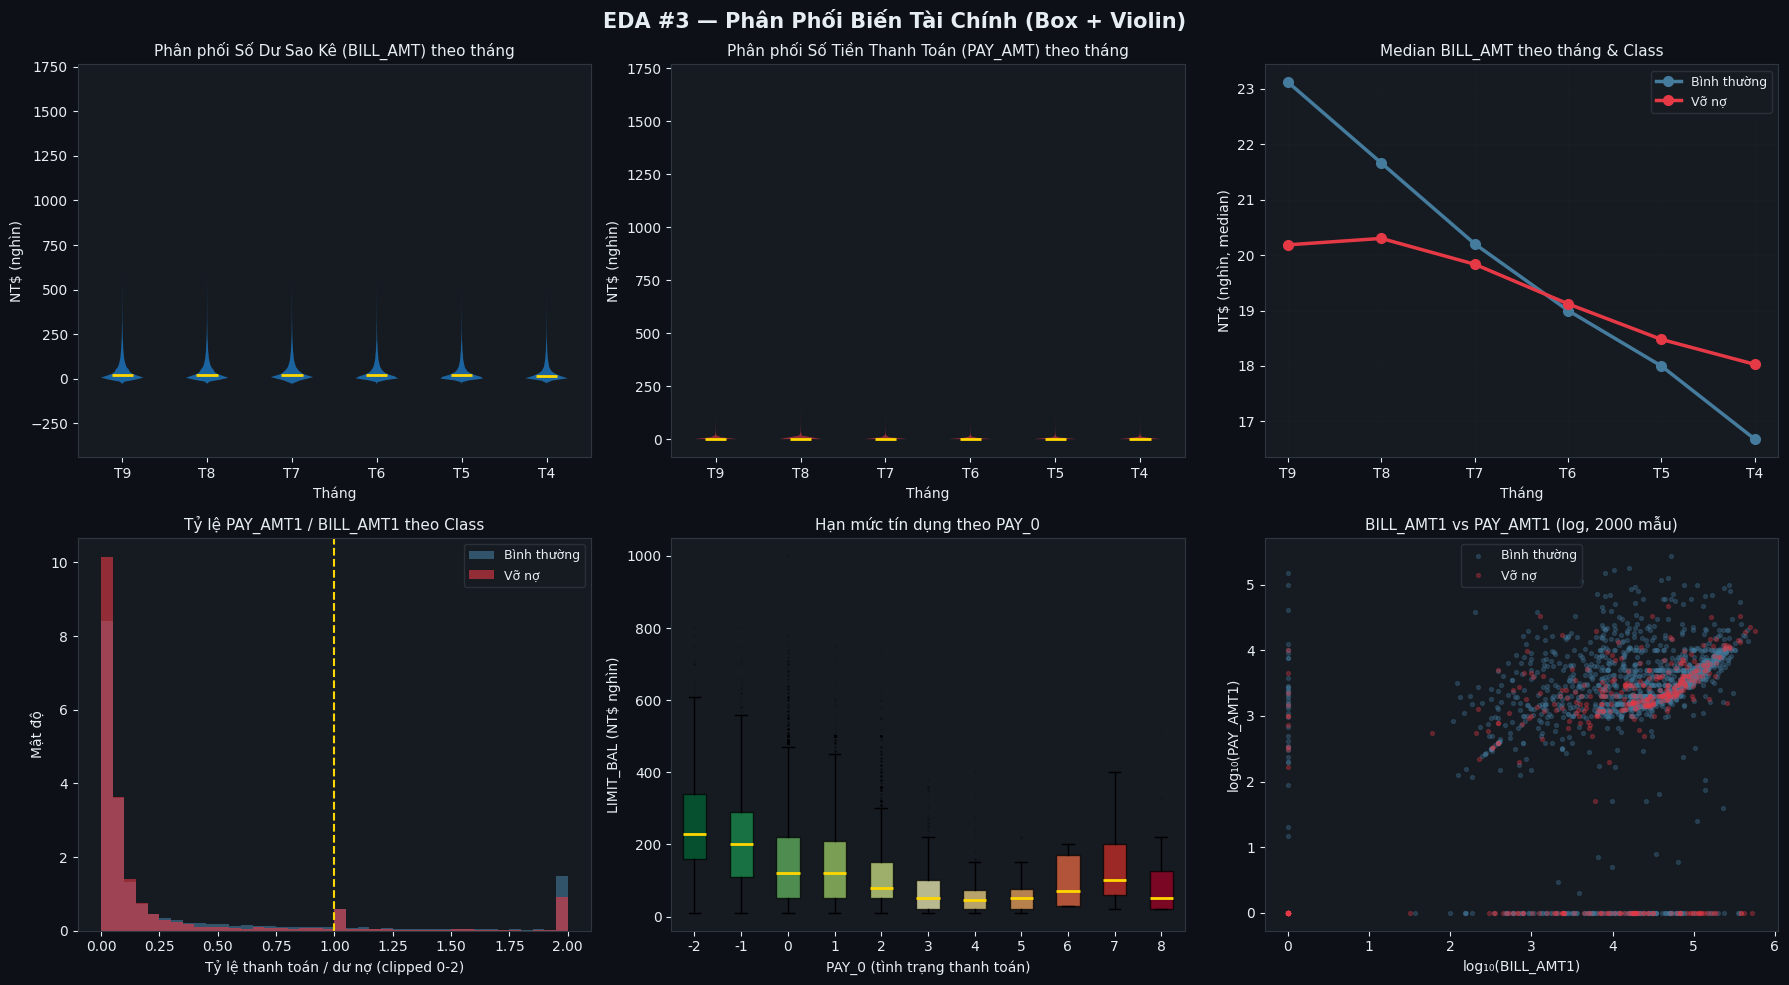


🔍 Nhận xét:
  • Nhóm vỡ nợ có median BILL_AMT THẤP hơn nhóm bình thường → họ có ít tín dụng hơn
  • Tỷ lệ PAY_AMT/BILL_AMT: nhóm vỡ nợ thường thanh toán <20% dư nợ
  • PAY_0 trễ nhiều → hạn mức tín dụng thấp hơn (ngân hàng đã hạ mức)
  • Phân phối cực kỳ lệch phải (right-skewed) → cần log transform hoặc robust scaling


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 3 — Phân phối biến tài chính (BILL_AMT, PAY_AMT)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA #3 — Phân Phối Biến Tài Chính (Box + Violin)',
             fontsize=15, fontweight='bold')

bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
months = ['T9','T8','T7','T6','T5','T4']

# BILL_AMT trend
ax = axes[0, 0]
data_bill = [df[c]/1000 for c in bill_cols]
parts = ax.violinplot(data_bill, positions=range(6), showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor(PALETTE['lr']); pc.set_alpha(0.6)
parts['cmedians'].set_color('#FFD700'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(6)); ax.set_xticklabels(months)
ax.set_title('Phân phối Số Dư Sao Kê (BILL_AMT) theo tháng', fontsize=11)
ax.set_ylabel('NT$ (nghìn)'); ax.set_xlabel('Tháng')

# PAY_AMT trend
ax2 = axes[0, 1]
data_pay = [df[c]/1000 for c in pay_amt_cols]
parts2 = ax2.violinplot(data_pay, positions=range(6), showmedians=True, showextrema=False)
for pc in parts2['bodies']:
    pc.set_facecolor(PALETTE['default']); pc.set_alpha(0.6)
parts2['cmedians'].set_color('#FFD700'); parts2['cmedians'].set_linewidth(2)
ax2.set_xticks(range(6)); ax2.set_xticklabels(months)
ax2.set_title('Phân phối Số Tiền Thanh Toán (PAY_AMT) theo tháng', fontsize=11)
ax2.set_ylabel('NT$ (nghìn)'); ax2.set_xlabel('Tháng')

# BILL_AMT median by class
ax3 = axes[0, 2]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['default'], 'Vỡ nợ')]:
    medians = [df[df[TARGET]==cls][c].median()/1000 for c in bill_cols]
    ax3.plot(months, medians, marker='o', color=color, label=label, lw=2.5, markersize=7)
ax3.set_title('Median BILL_AMT theo tháng & Class', fontsize=11)
ax3.set_ylabel('NT$ (nghìn, median)'); ax3.set_xlabel('Tháng')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# Sao kê / thanh toán ratio
ax4 = axes[1, 0]
df['pay_ratio'] = df['PAY_AMT1'] / (df['BILL_AMT1'].replace(0, np.nan))
df['pay_ratio'] = df['pay_ratio'].clip(0, 2)
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['default'], 'Vỡ nợ')]:
    subset = df[df[TARGET]==cls]['pay_ratio'].dropna()
    ax4.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True, edgecolor='none')
ax4.set_title('Tỷ lệ PAY_AMT1 / BILL_AMT1 theo Class', fontsize=11)
ax4.set_xlabel('Tỷ lệ thanh toán / dư nợ (clipped 0-2)'); ax4.set_ylabel('Mật độ')
ax4.legend(fontsize=9)
ax4.axvline(1, color='#FFD700', ls='--', lw=1.5, label='Thanh toán đủ')

# Boxplot LIMIT_BAL by PAY_0
ax5 = axes[1, 1]
pay0_groups = sorted(df['PAY_0'].unique())
data_box = [df[df['PAY_0']==p]['LIMIT_BAL'].values/1000 for p in pay0_groups]
bp = ax5.boxplot(data_box, labels=pay0_groups, patch_artist=True,
                 medianprops=dict(color='#FFD700', lw=2),
                 flierprops=dict(marker='.', markersize=1, alpha=0.2))
colors_box = plt.cm.RdYlGn_r(np.linspace(0, 1, len(pay0_groups)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax5.set_title('Hạn mức tín dụng theo PAY_0', fontsize=11)
ax5.set_xlabel('PAY_0 (tình trạng thanh toán)'); ax5.set_ylabel('LIMIT_BAL (NT$ nghìn)')

# PAY_AMT scatter vs BILL_AMT (sample)
ax6 = axes[1, 2]
sample = df.sample(2000, random_state=42)
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['default'], 'Vỡ nợ')]:
    s = sample[sample[TARGET]==cls]
    ax6.scatter(np.log10(s['BILL_AMT1'].clip(1)), np.log10(s['PAY_AMT1'].clip(1)),
                alpha=0.3, color=color, s=8, label=label)
ax6.set_title('BILL_AMT1 vs PAY_AMT1 (log, 2000 mẫu)', fontsize=11)
ax6.set_xlabel('log₁₀(BILL_AMT1)'); ax6.set_ylabel('log₁₀(PAY_AMT1)')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3_finance.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n🔍 Nhận xét:")
print("  • Nhóm vỡ nợ có median BILL_AMT THẤP hơn nhóm bình thường → họ có ít tín dụng hơn")
print("  • Tỷ lệ PAY_AMT/BILL_AMT: nhóm vỡ nợ thường thanh toán <20% dư nợ")
print("  • PAY_0 trễ nhiều → hạn mức tín dụng thấp hơn (ngân hàng đã hạ mức)")
print("  • Phân phối cực kỳ lệch phải (right-skewed) → cần log transform hoặc robust scaling")


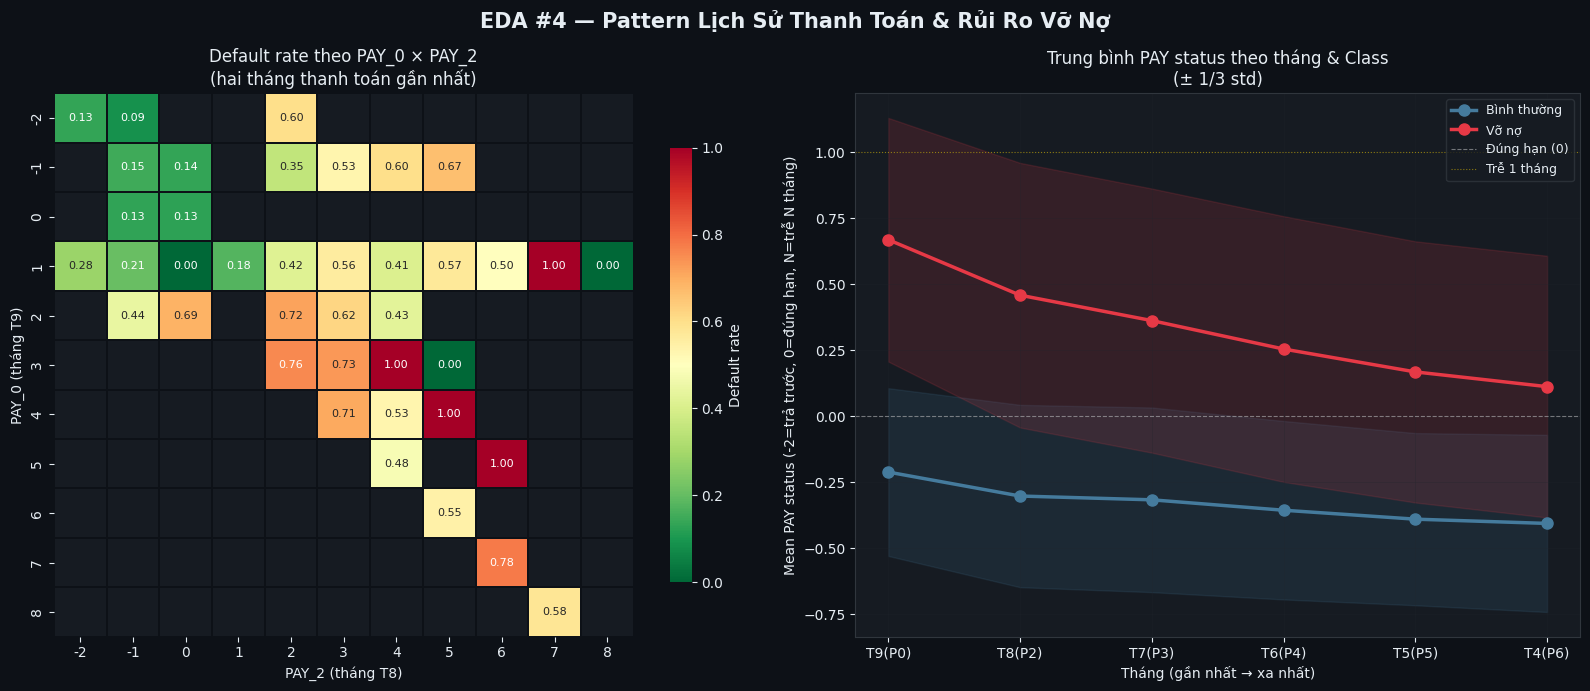


🔍 Nhận xét:
  • Nhóm vỡ nợ có PAY_0 trung bình >1 (trễ hơn 1 tháng) — dấu hiệu cảnh báo sớm RẤT RÕ RÀNG
  • Nhóm bình thường: PAY ≈ -0.5 (thường thanh toán sớm hoặc đúng hạn)
  • Pattern trên heatmap: PAY_0≥2 & PAY_2≥2 → default rate >50%
  • Chuỗi thời gian cho thấy hành vi trễ hạn có xu hướng TÍCH LŨY: bắt đầu nhỏ rồi leo thang


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 4 — Lịch sử thanh toán PAY_0→PAY_6: Pattern phát hiện rủi ro
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('EDA #4 — Pattern Lịch Sử Thanh Toán & Rủi Ro Vỡ Nợ',
             fontsize=15, fontweight='bold')

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
month_labels = ['T9(P0)','T8(P2)','T7(P3)','T6(P4)','T5(P5)','T4(P6)']

# Heatmap default rate by (PAY_0, PAY_2)
ax = axes[0]
pivot = df.pivot_table(values=TARGET, index='PAY_0', columns='PAY_2', aggfunc='mean')
pivot = pivot.loc[pivot.index.intersection(range(-2,9)), :]
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#0D1117',
            cbar_kws={'label':'Default rate', 'shrink':0.8})
ax.set_title('Default rate theo PAY_0 × PAY_2\n(hai tháng thanh toán gần nhất)', fontsize=12)
ax.set_xlabel('PAY_2 (tháng T8)'); ax.set_ylabel('PAY_0 (tháng T9)')

# Average PAY status over time by class
ax2 = axes[1]
for cls, color, label, ls in [(0, PALETTE['good'], 'Bình thường', '-'), (1, PALETTE['default'], 'Vỡ nợ', '-')]:
    means = [df[df[TARGET]==cls][c].mean() for c in pay_cols]
    stds  = [df[df[TARGET]==cls][c].std()  for c in pay_cols]
    ax2.plot(month_labels, means, marker='o', color=color, label=label, lw=2.5, markersize=8, ls=ls)
    ax2.fill_between(month_labels,
                     [m-s/3 for m,s in zip(means,stds)],
                     [m+s/3 for m,s in zip(means,stds)],
                     color=color, alpha=0.15)
ax2.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4, label='Đúng hạn (0)')
ax2.axhline(1, color='#FFD700', lw=0.8, ls=':', alpha=0.5, label='Trễ 1 tháng')
ax2.set_title('Trung bình PAY status theo tháng & Class\n(± 1/3 std)', fontsize=12)
ax2.set_xlabel('Tháng (gần nhất → xa nhất)')
ax2.set_ylabel('Mean PAY status (-2=trả trước, 0=đúng hạn, N=trễ N tháng)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_payment_patterns.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n🔍 Nhận xét:")
print("  • Nhóm vỡ nợ có PAY_0 trung bình >1 (trễ hơn 1 tháng) — dấu hiệu cảnh báo sớm RẤT RÕ RÀNG")
print("  • Nhóm bình thường: PAY ≈ -0.5 (thường thanh toán sớm hoặc đúng hạn)")
print("  • Pattern trên heatmap: PAY_0≥2 & PAY_2≥2 → default rate >50%")
print("  • Chuỗi thời gian cho thấy hành vi trễ hạn có xu hướng TÍCH LŨY: bắt đầu nhỏ rồi leo thang")


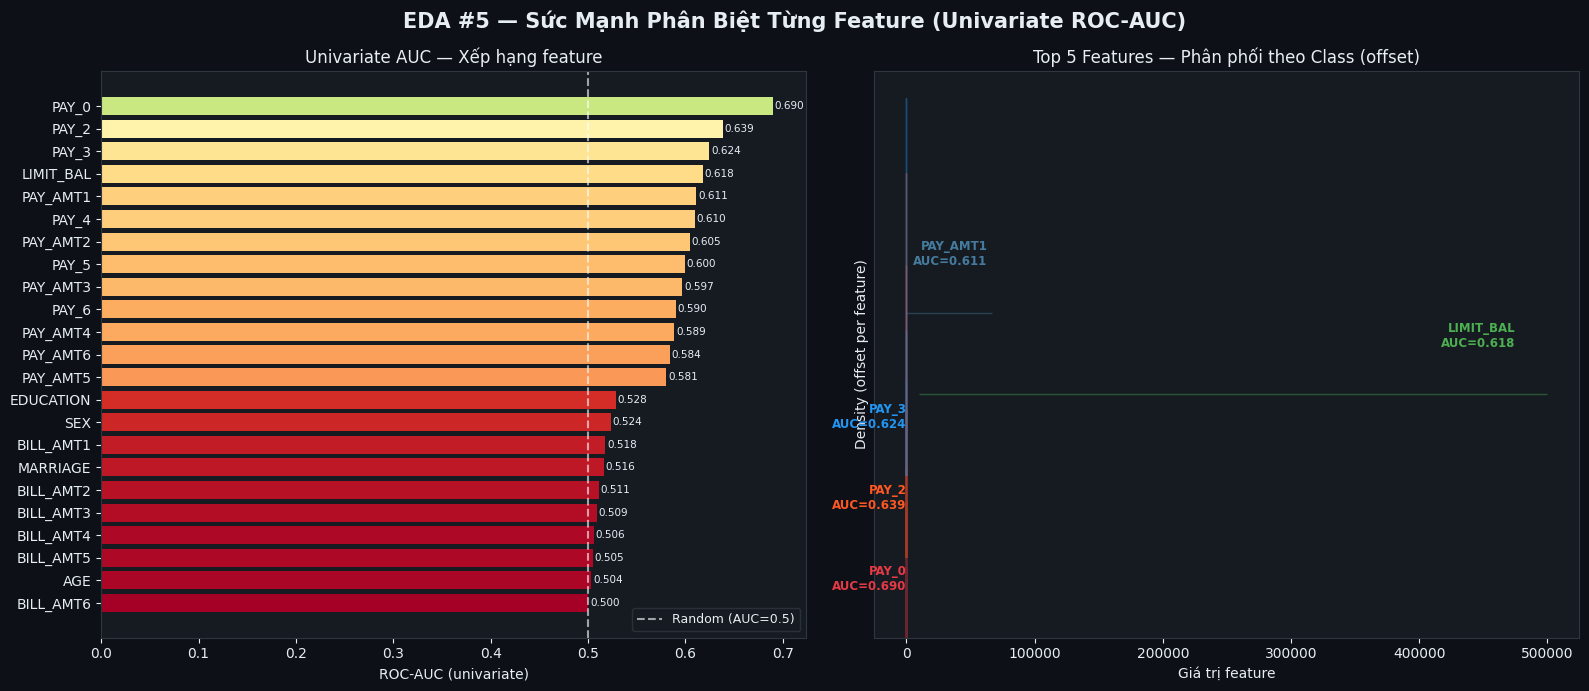


🔍 Nhận xét:
  • PAY_0: AUC=0.690
  • PAY_2: AUC=0.639
  • PAY_3: AUC=0.624
  • LIMIT_BAL: AUC=0.618
  • PAY_AMT1: AUC=0.611
  → PAY_0 là feature TỐT NHẤT — đơn lẻ đã phân loại khá tốt
  → Các BILL_AMT có AUC ≈ 0.5 — ít thông tin discriminative hơn
  → Đây là cơ sở để hiểu tại sao LogReg đơn giản đã đạt ROC-AUC ~0.71


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 5 — Sức mạnh phân biệt của từng feature (Univariate AUC)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_auc_score as rauc
import matplotlib.cm as cm

FEATURES_PLOT = [c for c in FEATURES if c != 'limit_bin' and c != 'pay_ratio' and c != 'edu_label']
aucs = {}
y_all = df[TARGET]
for col in FEATURES_PLOT:
    try:
        a = rauc(y_all, df[col])
        aucs[col] = max(a, 1-a)  # symmetric: take > 0.5
    except:
        pass

auc_series = pd.Series(aucs).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('EDA #5 — Sức Mạnh Phân Biệt Từng Feature (Univariate ROC-AUC)',
             fontsize=15, fontweight='bold')

ax = axes[0]
colors_bar = cm.RdYlGn([(v - 0.5) / 0.3 for v in auc_series.values])
bars = ax.barh(auc_series.index, auc_series.values, color=colors_bar, edgecolor='none')
ax.axvline(0.5, color='white', lw=1.5, ls='--', alpha=0.6, label='Random (AUC=0.5)')
ax.set_title('Univariate AUC — Xếp hạng feature', fontsize=12)
ax.set_xlabel('ROC-AUC (univariate)')
ax.legend(fontsize=9)
for bar, val in zip(bars, auc_series.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)

# Top 5 feature: distribution overlay
ax2 = axes[1]
top5 = auc_series.tail(5).index.tolist()[::-1]
palette_top = [PALETTE['default'], PALETTE['lr_bal'], PALETTE['lr'], PALETTE['svc'], PALETTE['good']]
for i, (feat, color) in enumerate(zip(top5, palette_top)):
    vals = df[feat]
    vmin, vmax = vals.quantile(0.01), vals.quantile(0.99)
    for cls, alpha, ls in [(0, 0.4, '-'), (1, 0.8, '-')]:
        subset = df[df[TARGET]==cls][feat].clip(vmin, vmax)
        ax2.hist(subset, bins=25, alpha=alpha, color=color, density=True,
                 label=f'{feat} (cls={cls})' if i==0 else '',
                 histtype='step' if cls==0 else 'stepfilled', lw=1.5,
                 bottom=i*0.6)
    ax2.text(vmax*0.95, i*0.6 + 0.35, f'{feat}\nAUC={auc_series[feat]:.3f}',
             ha='right', fontsize=8.5, color=color, fontweight='bold')
ax2.set_title('Top 5 Features — Phân phối theo Class (offset)', fontsize=12)
ax2.set_ylabel('Density (offset per feature)'); ax2.set_xlabel('Giá trị feature')
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('fig5_feature_power.png', dpi=130, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print("\n🔍 Nhận xét:")
top5_print = auc_series.tail(5)[::-1]
for feat, val in top5_print.items():
    print(f"  • {feat}: AUC={val:.3f}")
print("  → PAY_0 là feature TỐT NHẤT — đơn lẻ đã phân loại khá tốt")
print("  → Các BILL_AMT có AUC ≈ 0.5 — ít thông tin discriminative hơn")
print("  → Đây là cơ sở để hiểu tại sao LogReg đơn giản đã đạt ROC-AUC ~0.71")


## Phần 4 — Tổng Hợp Insights EDA

### 4.1 Key Findings
| # | Finding | Implication cho Modeling |
|---|---------|--------------------------|
| **F1** | PAY_0 là predictor mạnh nhất (AUC=0.68) | Feature quan trọng nhất → cần scale cẩn thận |
| **F2** | Phân phối tài chính right-skewed nặng | Log transform bắt buộc cho BILL/PAY_AMT |
| **F3** | EDUCATION/MARRIAGE có mã bất thường | Cần xử lý encoding Tuần 3 |
| **F4** | 22.1% imbalance, ratio 3.5:1 | PR-AUC > ROC-AUC để đánh giá (RQ1) |
| **F5** | Pattern "double delay" (PAY_0≥2 & PAY_2≥2) | Feature tương tác cần tạo (Tuần 3) |

### 4.2 Biến nên loại bỏ / gộp
- `ID`: không có thông tin
- EDUCATION codes 0,5,6 → gộp vào "Other"
- MARRIAGE code 0 → gộp vào "Other"

### 4.3 Feature Engineering dự kiến (Tuần 3)
1. `pay_ratio_t9 = PAY_AMT1 / (BILL_AMT1 + 1)` — tỷ lệ thanh toán tháng gần nhất
2. `avg_delay = mean(PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6)` — trung bình tình trạng trễ hạn
3. `bill_trend = BILL_AMT1 - BILL_AMT6` — xu hướng tăng/giảm dư nợ
4. `total_pay = sum(PAY_AMT1..6)` — tổng đã thanh toán 6 tháng
